# Stats 426 Project

### Setup

In [38]:
import os

import numpy as np 
import pandas as pd

from PIL import Image
from tqdm import tqdm

# Visualization / EDA 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Modeling
import torch

from sklearn.linear_model import LogisticRegression



In [2]:
# !pip3 install scikit-learn

### Loading in Data

In [3]:
'data/train/PNEUMONIA'
'data/train/NORMAL'

# TODO 

'data/train/NORMAL'

### Exploring the Dataset

In [4]:
def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))
    return normal, pneumonia

train_counts = count_images("data/train")
val_counts = count_images("data/val")
test_counts = count_images("data/test")

print('Number of Images per Data Partition in the Format of (# Normal, # Pneumonia)')
print("Train:", train_counts)
print("Val:", val_counts)
print("Test:", test_counts)

# TODO -- might convert this to a dataframe later for easier reading 

Number of Images per Data Partition in the Format of (# Normal, # Pneumonia)
Train: (1341, 3875)
Val: (8, 8)
Test: (234, 390)


In [5]:
# TODO -- plot class imbalance (slide 3)

# TODO -- we do have class imbalance & need to handle it somehow? 
# chatgpt says: loss = BCEWithLogitsLoss(pos_weight)
# or
# class_weight='balanced'
# or 
# resample (not rec'd bc low sample sizes?)

### Exploratory Data Analysis (EDA)

I was thinking we don't have to go too in depth here for the slides 

can add on later for when the paper is due 

### Baseline Model -- Logistic Regression or Shallow MLP

In [41]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.utils import shuffle

def load_images_and_labels(base_dir):
    data = []
    labels = []
    
    # Iterate through each subfolder (NORMAL, PNEUMONIA)
    for label in os.listdir(base_dir):
        label_dir = os.path.join(base_dir, label)
        if not os.path.isdir(label_dir):
            continue
        
        # Iterate through each image in the subfolder
        for image_name in tqdm(os.listdir(label_dir), desc=f"Processing {label_dir}"):
            image_path = os.path.join(label_dir, image_name)
            try:
                # Open the image and convert to grayscale
                img = Image.open(image_path).convert('L')
                # Resize the image to a fixed size (e.g., 64x64)
                img = img.resize((64, 64))
                # Flatten the image into a 1D array
                img_array = np.array(img).flatten()
                # Append the image data and label
                data.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error processing {image_path}: {e}")
    
    # Convert to DataFrame and shuffle
    df = pd.DataFrame(data)
    df['label'] = labels
    df = shuffle(df, random_state=42).reset_index(drop=True)
    return df

# Define the directories
train_dir = 'data/train'
test_dir = 'data/test'
val_dir = 'data/val'

# Load the datasets
train_df = load_images_and_labels(train_dir)
test_df = load_images_and_labels(test_dir)
val_df = load_images_and_labels(val_dir)

X_train, y_train = train_df.drop('label', axis=1), train_df['label']
X_test, y_test = test_df.drop('label', axis=1), test_df['label']
X_val, y_val = val_df.drop('label', axis=1), val_df['label']

print("DataFrames created, shuffled, and saved successfully!")

Processing data/val\PNEUMONIA: 100%|██████████| 8/8 [00:00<00:00, 169.32it/s]


DataFrames created, shuffled, and saved successfully!


In [42]:
# Train
model = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train, y_train)
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [43]:
# Evaluate 
y_pred = model.predict(X_test)
model.score(X_test, y_test)

0.7451923076923077

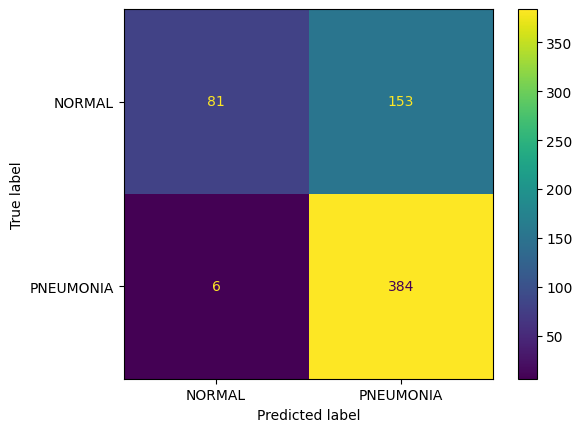

In [44]:
# Visualize Results
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

### CNN

In [10]:
# PyTorch Dataloader

In [11]:
# Define CNN Class like from hw???

In [12]:
# Train 

In [13]:
# Evaluate